### データの読み込み

In [107]:
import numpy as np
import json
from Users import GetLabels

user1_ratings, user2_ratings, user3_ratings= GetLabels.getLabels()

with open('Restaurants/Features.json', 'r', encoding='utf-8') as f:
    features = json.load(f)

feature_names = [
        "中華", "居酒屋", "ダイニングバー・バル", "和食", 
        "お好み焼き・もんじゃ", "韓国料理", "イタリアン・フレンチ", 
        "焼肉・ホルモン", "洋食", "アジア・エスニック料理", 
        "創作料理", "各国料理", "ラーメン","予算","個室", "喫煙","wifi",
        "カード", "駐車場", "総合評価"
    ]

#numpy形式に変換
features_np = np.array(features)
user1_ratings_np = np.array(user1_ratings)
user2_ratings_np = np.array(user2_ratings)
user3_ratings_np = np.array(user3_ratings)

### 10フォールド交差検証

In [108]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
import japanize_matplotlib

 # KFoldインスタンスを初期化
kf = KFold(n_splits=10, shuffle=True, random_state=0)

# NumPy配列をリスト形式の文字列に変換する関数
def array_to_list_string(array):
    formatted_array = []
    for elem in array:
        if np.isclose(elem, np.round(elem)):
            # np.iscloseで浮動小数点数が整数に近いか確認し、整数に変換
            formatted_array.append(str(int(np.round(elem))))
        else:
            # 浮動小数点数はそのままの形式で追加
            formatted_array.append(str(elem))
    return '[' + ', '.join(formatted_array) + ']'

def crossValidation(user_ratings_np):
    # 各フォールドの正解率を格納するリスト
    accuracies = []

    # 適合率を格納するリスト
    precisions = []
    positive_class_ratios = []

    # フォールド番号を1から始めるためのカウンター
    fold_counter = 1

    # KFoldで分割されたインデックスを使ってループ
    for train_index, test_index in kf.split(features):
        # トレーニングとテストセットを作成します。
        X_train, X_test = features_np[train_index], features_np[test_index]
        y_train, y_test = user_ratings_np[train_index], user_ratings_np[test_index]

        # 決定木の分類器を作成し、トレーニングデータにフィット
        classifier = DecisionTreeClassifier(random_state=0)
        classifier.fit(X_train, y_train)

        # テストデータに対する予測
        predictions = classifier.predict(X_test)

        # 正解率を計算し、リストに追加
        accuracy = accuracy_score(y_test, predictions)
        accuracies.append(accuracy)

        # 適合率を計算し、リストに追加
        precision = precision_score(y_test, predictions, zero_division=0)
        precisions.append(precision)
        
        # テストセットに含まれる陽性クラスの割合を計算し、リストに追加
        positive_class_ratio = np.mean(y_test)
        positive_class_ratios.append(positive_class_ratio)

        # 決定木のプロット
        """plt.figure(figsize=(20,10))
        plot_tree(classifier, filled=True, feature_names=feature_names)
        plt.title(f'Decision Tree for Fold {fold_counter}')
        plt.show()"""

        # 正しく予測できなかったインスタンスを出力
        """incorrect_indices = np.where(predictions != y_test)[0]
        print(f'Fold {fold_counter}')
        for index in incorrect_indices:
        # 出力
            print(f'Feature: {array_to_list_string(X_test[index])}')
            print(f'True Label: {y_test[index]}')
            print(f'Predicted Label: {predictions[index]}')
            print("---")"""

        # フォールドの正解率を出力
        print(f'Fold {fold_counter}: Accuracy = {accuracy}')
        
        # 次のフォールドへのカウンターを増やす
        fold_counter += 1

    # 全フォールドでの平均正解率を出力
    mean_accuracy = np.mean(accuracies)
    print(f'Mean Accuracy across all folds: {mean_accuracy}\n')

    return precisions, positive_class_ratios,accuracies

print("User1")
user1_precisions, positive_class_ratios, user1_accuracies = crossValidation(user1_ratings_np)
print("User2")
user2_precisions, _, user2_accuracies = crossValidation(user2_ratings_np)
print("User3")
user3_precisions, _, user3_accuracies = crossValidation(user3_ratings_np)

User1
Fold 1: Accuracy = 0.6
Fold 2: Accuracy = 0.2
Fold 3: Accuracy = 0.9
Fold 4: Accuracy = 0.6
Fold 5: Accuracy = 0.8
Fold 6: Accuracy = 0.6
Fold 7: Accuracy = 0.7
Fold 8: Accuracy = 0.5
Fold 9: Accuracy = 0.9
Fold 10: Accuracy = 0.8
Mean Accuracy across all folds: 0.6599999999999999

User2
Fold 1: Accuracy = 1.0
Fold 2: Accuracy = 0.9
Fold 3: Accuracy = 0.9
Fold 4: Accuracy = 1.0
Fold 5: Accuracy = 0.9
Fold 6: Accuracy = 0.9
Fold 7: Accuracy = 0.7
Fold 8: Accuracy = 1.0
Fold 9: Accuracy = 1.0
Fold 10: Accuracy = 1.0
Mean Accuracy across all folds: 0.93

User3
Fold 1: Accuracy = 1.0
Fold 2: Accuracy = 1.0
Fold 3: Accuracy = 0.9
Fold 4: Accuracy = 1.0
Fold 5: Accuracy = 1.0
Fold 6: Accuracy = 1.0
Fold 7: Accuracy = 1.0
Fold 8: Accuracy = 1.0
Fold 9: Accuracy = 1.0
Fold 10: Accuracy = 1.0
Mean Accuracy across all folds: 0.99



### 正規分布に従っているかどうかの検定

In [109]:
from scipy import stats

def shapiro(precisions):
    # 決定木モデルの平均適合率
    mean_precision_tree = np.mean(precisions)
    print(precisions)
    # ランダム手法の平均適合率の計算
    mean_precision_random = np.mean([positive_class_ratios])
    print(positive_class_ratios)

    # 検定の実施
    w_stat, p_value = stats.shapiro(precisions-np.array(positive_class_ratios))

    print(f"決定木モデルの平均適合率: {mean_precision_tree}")
    print(f"ランダム手法の平均適合率: {mean_precision_random}")
    print(f"検定結果: 統計量 = {w_stat}, p値 = {p_value}")
    print("\n")
    
print("User1")
shapiro(user1_precisions)
print("User2")
shapiro(user2_precisions)
print("User3")
shapiro(user3_precisions)

User1
[0.5, 0.16666666666666666, 0.5, 0.3333333333333333, 1.0, 0.6, 1.0, 0.5, 1.0, 0.6666666666666666]
[0.4, 0.4, 0.1, 0.3, 0.7, 0.5, 0.4, 0.5, 0.7, 0.4]
決定木モデルの平均適合率: 0.6266666666666667
ランダム手法の平均適合率: 0.44000000000000006
検定結果: 統計量 = 0.9781174659729004, p値 = 0.9543020129203796


User2
[1.0, 0.8, 0.6666666666666666, 1.0, 0.8571428571428571, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.4, 0.4, 0.1, 0.3, 0.7, 0.5, 0.4, 0.5, 0.7, 0.4]
決定木モデルの平均適合率: 0.9323809523809524
ランダム手法の平均適合率: 0.44000000000000006
検定結果: 統計量 = 0.9070867896080017, p値 = 0.2615737318992615


User3
[1.0, 1.0, 0.8, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.4, 0.4, 0.1, 0.3, 0.7, 0.5, 0.4, 0.5, 0.7, 0.4]
決定木モデルの平均適合率: 0.9800000000000001
ランダム手法の平均適合率: 0.44000000000000006
検定結果: 統計量 = 0.8470516800880432, p値 = 0.053576383739709854




### ウィルコクソンの符号順位検定(適合率)
・交差検証の結果を使って, 検定を行った.

In [110]:
from scipy import stats

def wilcoxon(precisions):
    # 決定木モデルの平均適合率
    mean_precision_tree = np.mean(precisions)
    print(precisions)
    # ランダム手法の平均適合率の計算
    mean_precision_random = np.mean([positive_class_ratios])
    print(positive_class_ratios)

    # 検定の実施
    w_stat, p_value = stats.wilcoxon(precisions, positive_class_ratios, alternative='greater')

    print(f"決定木モデルの平均適合率: {mean_precision_tree}")
    print(f"ランダム手法の平均適合率: {mean_precision_random}")
    print(f"検定結果: 統計量 = {w_stat}, p値 = {p_value}")
    print("\n")
    
print("User1")
wilcoxon(user1_precisions)
print("User2")
wilcoxon(user2_precisions)
print("User3")
wilcoxon(user3_precisions)

User1
[0.5, 0.16666666666666666, 0.5, 0.3333333333333333, 1.0, 0.6, 1.0, 0.5, 1.0, 0.6666666666666666]
[0.4, 0.4, 0.1, 0.3, 0.7, 0.5, 0.4, 0.5, 0.7, 0.4]
決定木モデルの平均適合率: 0.6266666666666667
ランダム手法の平均適合率: 0.44000000000000006
検定結果: 統計量 = 41.0, p値 = 0.014062225058692448


User2
[1.0, 0.8, 0.6666666666666666, 1.0, 0.8571428571428571, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.4, 0.4, 0.1, 0.3, 0.7, 0.5, 0.4, 0.5, 0.7, 0.4]
決定木モデルの平均適合率: 0.9323809523809524
ランダム手法の平均適合率: 0.44000000000000006
検定結果: 統計量 = 55.0, p値 = 0.0009765625


User3
[1.0, 1.0, 0.8, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.4, 0.4, 0.1, 0.3, 0.7, 0.5, 0.4, 0.5, 0.7, 0.4]
決定木モデルの平均適合率: 0.9800000000000001
ランダム手法の平均適合率: 0.44000000000000006
検定結果: 統計量 = 55.0, p値 = 0.0009765625




/opt/homebrew/lib/python3.11/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/opt/homebrew/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


### ウィルコクソンの符号順位検定(正解率)

In [111]:
from scipy import stats

def wilcoxon(accuracies):
    # 決定木モデルの平均適合率
    mean_accuracy_tree = np.mean(accuracies)
    print(accuracies)
    # ランダム手法の平均適合率の計算
    accuracy_random = [0.5] * 10
    mean_accuracy_random = np.mean(accuracy_random)
    print(accuracy_random)

    # 検定の実施
    w_stat, p_value = stats.wilcoxon(accuracies, accuracy_random, alternative='greater')

    print(f"決定木モデルの平均正解率: {mean_accuracy_tree}")
    print(f"ランダム手法の平均正解率: {mean_accuracy_random}")
    print(f"検定結果: 統計量 = {w_stat}, p値 = {p_value}")
    print("\n")


print("User1")
wilcoxon(user1_accuracies)
print("User2")
wilcoxon(user2_accuracies)
print("User3")
wilcoxon(user3_accuracies)

User1
[0.6, 0.2, 0.9, 0.6, 0.8, 0.6, 0.7, 0.5, 0.9, 0.8]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
決定木モデルの平均正解率: 0.6599999999999999
ランダム手法の平均正解率: 0.5
検定結果: 統計量 = 40.0, p値 = 0.01857009518419652


User2
[1.0, 0.9, 0.9, 1.0, 0.9, 0.9, 0.7, 1.0, 1.0, 1.0]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
決定木モデルの平均正解率: 0.93
ランダム手法の平均正解率: 0.5
検定結果: 統計量 = 55.0, p値 = 0.0009765625


User3
[1.0, 1.0, 0.9, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
決定木モデルの平均正解率: 0.99
ランダム手法の平均正解率: 0.5
検定結果: 統計量 = 55.0, p値 = 0.0009765625




### 訓練データを増やした推移
・各フォールドで訓練データ20, 30, 50, 70, 90と増やし, 正解率と適合率の平均を取ってプロットしている

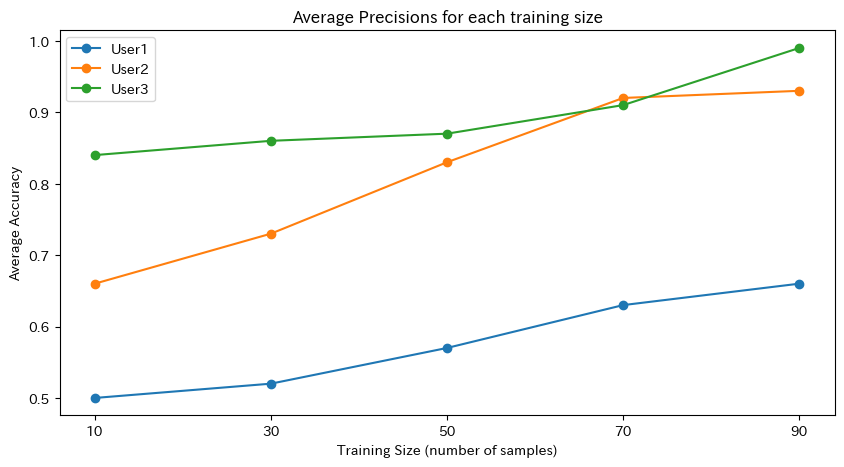

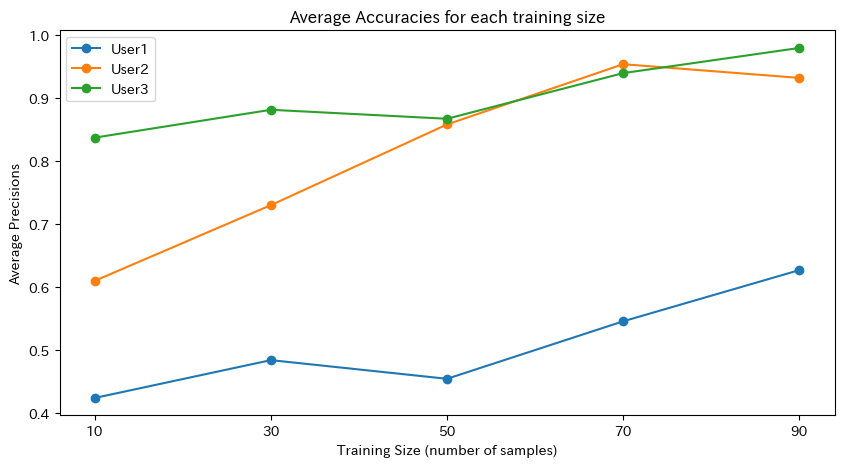

In [112]:
from sklearn.metrics import classification_report
from sklearn.model_selection import KFold

# 指定された訓練データのサイズ
training_sizes = [10, 30, 50, 70, 90]
def train(user_ratings_np):
     
    mean_accuracies = {size: [] for size in training_sizes}
    mean_precisions = {size: [] for size in training_sizes}

    for train_index, test_index in kf.split(features_np):
        # テストデータを固定
        X_test, y_test = features_np[test_index], user_ratings_np[test_index]

        for size in training_sizes:
            # 訓練データを指定されたサイズで取得
            X_train = features_np[train_index[:size]]
            y_train = user_ratings_np[train_index[:size]]

            # モデルを訓練
            classifier = DecisionTreeClassifier(random_state=0)
            classifier.fit(X_train, y_train)

            # テストデータに対する予測
            predictions = classifier.predict(X_test)

            # 正解率と適合率を計算
            accuracy = accuracy_score(y_test, predictions)
            precision = precision_score(y_test, predictions, zero_division=0)

            # スコアをリストに追加
            mean_accuracies[size].append(accuracy)
            mean_precisions[size].append(precision)

    # 各訓練サイズについて平均スコアを計算
    final_accuracies = [np.mean(mean_accuracies[size]) for size in training_sizes]
    final_precisions = [np.mean(mean_precisions[size]) for size in training_sizes]

    return final_accuracies, final_precisions

user1_final_accuracies, user1_final_precisions = train(user1_ratings_np)
user2_final_accuracies, user2_final_precisions = train(user2_ratings_np)
user3_final_accuracies, user3_final_precisions = train(user3_ratings_np)

# 正解率をプロット
plt.figure(figsize=(10, 5))
plt.plot(training_sizes, user1_final_accuracies, label='User1', marker='o')
plt.plot(training_sizes, user2_final_accuracies, label='User2', marker='o')
plt.plot(training_sizes, user3_final_accuracies, label='User3', marker='o')
plt.title('Average Precisions for each training size')
plt.xlabel('Training Size (number of samples)')
plt.ylabel('Average Accuracy')
plt.xticks(training_sizes)
plt.legend()
plt.show()

# 適合率をプロット
plt.figure(figsize=(10, 5))
plt.plot(training_sizes, user1_final_precisions, label='User1', marker='o')
plt.plot(training_sizes, user2_final_precisions, label='User2', marker='o')
plt.plot(training_sizes, user3_final_precisions, label='User3', marker='o')
plt.title('Average Accuracies for each training size')
plt.xlabel('Training Size (number of samples)')
plt.ylabel('Average Precisions')
plt.xticks(training_sizes)
plt.legend()
plt.show()


### 他の手法との比較

In [113]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.model_selection import KFold

# モデルの初期化
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Logistic Regression": LogisticRegression(random_state=0, max_iter=500),
    "k-NN": KNeighborsClassifier()
}

# 結果を格納するための辞書
results = {name: {"Accuracy": [], "Precision": [], "Recall": [], "F1": []} for name in models.keys()}

# 各モデルに対して交差検証を行う
for name, model in models.items():
    for train_index, test_index in kf.split(features):
        # トレーニングとテストセットを作成
        X_train, X_test = features_np[train_index], features_np[test_index]
        y_train, y_test = user3_ratings_np[train_index], user3_ratings_np[test_index]

        # モデルを訓練
        model.fit(X_train, y_train)

        # テストデータに対する予測
        predictions = model.predict(X_test)

        # 精度と適合率を計算し、リストに追加
        accuracy = accuracy_score(y_test, predictions)
        precision = precision_score(y_test, predictions)
        recall = recall_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)

        results[name]["Accuracy"].append(accuracy)
        results[name]["Precision"].append(precision)
        results[name]["Recall"].append(recall)
        results[name]["F1"].append(f1)

# 結果の表示
for name, scores in results.items():
    mean_accuracy = np.mean(scores["Accuracy"])
    mean_precision = np.mean(scores["Precision"])
    mean_recall = np.mean(scores["Recall"])
    mean_f1 = np.mean(scores["F1"])
    print(name)
    print(f"Mean Accuracy: {mean_accuracy}, Mean Precision: {mean_precision}, Mean Recall: {mean_recall}, Mean_F1: {mean_f1}\n")

Decision Tree
Mean Accuracy: 0.99, Mean Precision: 0.9800000000000001, Mean Recall: 1.0, Mean_F1: 0.9888888888888889

SVM
Mean Accuracy: 0.6199999999999999, Mean Precision: 0.5652380952380952, Mean Recall: 1.0, Mean_F1: 0.7182034632034632

Logistic Regression
Mean Accuracy: 0.9, Mean Precision: 0.9273809523809524, Mean Recall: 0.8716666666666667, Mean_F1: 0.8932817182817182

k-NN
Mean Accuracy: 0.6599999999999999, Mean Precision: 0.6799999999999999, Mean Recall: 0.6416666666666667, Mean_F1: 0.6237950937950939

